# Calibration Size: Personalised Movement Modelling

This notebook investigates how much participant-specific calibration data is required to improve movement classification.

The experiment varies the number of calibration trials available from a held-out participant while keeping the evaluation set fixed.

A generic model is trained on the other participant and evaluated on the held-out participant. A personalised model is then trained by adding participant-specific calibration trials to the same generic training data.

The reduced 18-feature representation is used because it provided better cross-participant performance than the full representation in the baseline feature ablation, while using fewer features.

Calibration is evaluated at four levels:

- 0 trials per movement class
- 1 trial per movement class
- 2 trials per movement class
- 5 trials per movement class

Five trials per movement class are held out as a fixed unseen test set for every calibration level.

This allows performance differences to be attributed to the amount of participant-specific calibration data rather than changes in the evaluation set.

## Experimental Setup

For each target participant:

1. Select five trials per movement class as the fixed test set.
2. Keep these test trials completely unseen during training and calibration.
3. Use the remaining five trials per movement class as the calibration pool.
4. Train the generic model using data from the other participant.
5. Add 0, 1, 2, or 5 calibration trials per class from the target participant.
6. Evaluate the resulting personalised model on the same fixed test set.

The generic model corresponds to zero participant-specific calibration. Because each participant has five trials per movement class in each session, the fixed test set consists of Session 01 trials, while the calibration pool consists of Session 02 trials. Calibration therefore uses participant-specific data from a separate recording session from the fixed evaluation set.

The experiment therefore measures whether increasing participant-specific information produces progressively better classification performance.

An additional methodological strength of this split is that the fixed test set consists entirely of Session 01 trials, while the calibration pool consists entirely of Session 02 trials for each participant. The evaluation therefore measures cross-session generalisation rather than performance on trials from the same recording session used for calibration.

Because only two participants are available, the results are exploratory and should not be interpreted as evidence of generalisation to a larger population.

In [1]:
# Imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
DATA_DIR = Path("../data/movement")

IDENTIFIER_COLUMNS = [
    "participant_id",
    "session_id",
    "trial_id",
    "movement_label",
]

FEATURE_COLUMNS = [
    "shoulder_width",
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "movement_speed",
    "head_offset_z",
    "torso_dz",
    "movement_speed_3d",
]

TARGET_COLUMN = "movement_label"

GROUP_COLUMNS = [
    "participant_id",
    "session_id",
    "trial_id",
    "movement_label",
]

REDUCED_STATISTICS = [
    "mean",
    "std",
]

CALIBRATION_LEVELS = [
    0,
    1,
    2,
    5,
]

TEST_TRIALS_PER_CLASS = 5

RANDOM_STATE = 42

In [3]:
# Load dataset

files = sorted(DATA_DIR.glob("P*_S*.csv"))

if not files:
    raise FileNotFoundError(
        f"No participant/session CSV files found in {DATA_DIR.resolve()}"
    )

frames = [pd.read_csv(file) for file in files]

df = pd.concat(
    frames,
    ignore_index=True,
)

print(f"Files loaded: {len(files)}")
print(f"Dataset shape: {df.shape}")

Files loaded: 4
Dataset shape: (5555, 14)


In [4]:
display(
    df[
        [
            "participant_id",
            "session_id",
            "trial_id",
            "movement_label",
        ]
    ].head()
)

,participant_id,session_id,trial_id,movement_label
0,P01,S01,1,neutral
1,P01,S01,1,neutral
2,P01,S01,1,neutral
3,P01,S01,1,neutral
4,P01,S01,1,neutral


In [5]:
# Trial-level representation

trial_features = (
    df.groupby(GROUP_COLUMNS)[FEATURE_COLUMNS]
    .agg(REDUCED_STATISTICS)
)

trial_features.columns = [
    f"{feature}_{stat}"
    for feature, stat in trial_features.columns
]

trial_features = trial_features.reset_index()

reduced_feature_columns = [
    f"{feature}_{stat}"
    for feature in FEATURE_COLUMNS
    for stat in REDUCED_STATISTICS
]

print(f"Trials: {len(trial_features)}")
print(f"Modelling features: {len(reduced_feature_columns)}")

display(trial_features.head())

Trials: 100
Modelling features: 18


,participant_id,session_id,trial_id,movement_label,shoulder_width_mean,shoulder_width_std,head_offset_x_mean,head_offset_x_std,head_offset_y_mean,head_offset_y_std,torso_dx_mean,torso_dx_std,torso_dy_mean,torso_dy_std,movement_speed_mean,movement_speed_std,head_offset_z_mean,head_offset_z_std,torso_dz_mean,torso_dz_std,movement_speed_3d_mean,movement_speed_3d_std
0,P01,S01,1,neutral,0.333478,0.001824,0.027531,0.005356,-0.892127,0.013139,-0.000470,0.001788,0.002372,0.003835,0.043863,0.058488,-0.634818,0.006986,0.000829,0.009888,0.108272,0.103189
1,P01,S01,2,neutral,0.335893,0.000788,0.037758,0.003797,-1.033394,0.012667,-0.000008,0.000514,0.000202,0.001966,0.021114,0.022412,-0.535309,0.022043,0.001613,0.029885,0.384039,0.378843
2,P01,S01,3,neutral,0.333582,0.001072,0.029839,0.004679,-0.960535,0.008964,-0.000016,0.000351,-0.000060,0.001102,0.013270,0.013942,-0.591936,0.005654,-0.000329,0.007374,0.088512,0.085349
3,P01,S01,4,neutral,0.335082,0.000511,0.041286,0.003732,-0.931393,0.009354,0.000078,0.000487,0.000136,0.001519,0.016416,0.015690,-0.604767,0.008319,-0.000259,0.005510,0.086544,0.055718
4,P01,S01,5,neutral,0.336775,0.000574,0.042007,0.003948,-0.916819,0.009203,0.000017,0.000464,0.000445,0.002508,0.028936,0.028535,-0.602010,0.006255,-0.000800,0.010731,0.133506,0.117260


In [6]:
# Trial-level dataset overview

print(
    f"Participants: "
    f"{trial_features['participant_id'].nunique()}"
)

print(
    f"Sessions: "
    f"{len(trial_features[['participant_id', 'session_id']].drop_duplicates())}"
)

print(
    f"Trials: "
    f"{len(trial_features)}"
)

print(
    f"Movement classes: "
    f"{trial_features[TARGET_COLUMN].nunique()}"
)

display(
    trial_features[TARGET_COLUMN]
    .value_counts()
    .sort_index()
)

Participants: 2
Sessions: 4
Trials: 100
Movement classes: 5


movement_label
lean_forward    20
lean_left       20
lean_right      20
neutral         20
raise_arms      20
Name: count, dtype: int64

In [7]:
# Participant evaluation

participants = sorted(
    trial_features["participant_id"].unique()
)

print("Participants:")

for participant in participants:
    print(f"  - {participant}")

Participants:
  - P01
  - P02


In [8]:
# Feature Representation

# The calibration-size experiment uses the reduced representation 
# identified in the preceding feature ablation experiment.
# It contains 18 features:
# - 9 frame-level movement features
# - mean and standard deviation for each feature

print(
    f"Reduced representation: "
    f"{len(reduced_feature_columns)} features"
)

display(
    pd.DataFrame(
        {
            "feature": reduced_feature_columns
        }
    )
)

Reduced representation: 18 features


,feature
0,shoulder_width_mean
1,shoulder_width_std
2,head_offset_x_mean
3,head_offset_x_std
4,head_offset_y_mean
5,head_offset_y_std
6,torso_dx_mean
7,torso_dx_std
8,torso_dy_mean
9,torso_dy_std


In [9]:
# Model
# The same Logistic Regression pipeline used in the baseline and 
# personalised modelling experiments is used here.
# Standardisation is fitted only on the training data through the pipeline.

def create_model():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

In [10]:
# Fixed Test and Calibration Pools

test_sets = {}
calibration_pools = {}

movements = sorted(
    trial_features[TARGET_COLUMN].unique()
)

for participant in participants:

    participant_data = trial_features[
        trial_features["participant_id"] == participant
    ].copy()

    test_indices = []
    calibration_indices = []

    for movement in movements:

        movement_data = (
            participant_data[
                participant_data[TARGET_COLUMN] == movement
            ]
            .sort_values(
                [
                    "session_id",
                    "trial_id",
                ]
            )
        )

        movement_indices = movement_data.index.tolist()

        if len(movement_indices) < (
            TEST_TRIALS_PER_CLASS + max(CALIBRATION_LEVELS)
        ):
            raise ValueError(
                f"{participant} / {movement} does not have enough trials."
            )

        test_indices.extend(
            movement_indices[:TEST_TRIALS_PER_CLASS]
        )

        calibration_indices.extend(
            movement_indices[TEST_TRIALS_PER_CLASS:]
        )

    test_sets[participant] = trial_features.loc[
        sorted(test_indices)
    ].copy()

    calibration_pools[participant] = trial_features.loc[
        sorted(calibration_indices)
    ].copy()

    print(
        f"{participant}: "
        f"{len(test_sets[participant])} fixed test trials, "
        f"{len(calibration_pools[participant])} calibration-pool trials"
    )

P01: 25 fixed test trials, 25 calibration-pool trials
P02: 25 fixed test trials, 25 calibration-pool trials


In [11]:
for participant in participants:

    print(f"\n{participant} — Fixed test set")

    display(
        test_sets[participant][TARGET_COLUMN]
        .value_counts()
        .sort_index()
    )

    print(f"{participant} — Calibration pool")

    display(
        calibration_pools[participant][TARGET_COLUMN]
        .value_counts()
        .sort_index()
    )


P01 — Fixed test set


movement_label
lean_forward    5
lean_left       5
lean_right      5
neutral         5
raise_arms      5
Name: count, dtype: int64

P01 — Calibration pool


movement_label
lean_forward    5
lean_left       5
lean_right      5
neutral         5
raise_arms      5
Name: count, dtype: int64


P02 — Fixed test set


movement_label
lean_forward    5
lean_left       5
lean_right      5
neutral         5
raise_arms      5
Name: count, dtype: int64

P02 — Calibration pool


movement_label
lean_forward    5
lean_left       5
lean_right      5
neutral         5
raise_arms      5
Name: count, dtype: int64

In [12]:
# Verify the split

for participant in participants:

    test_indices = set(
        test_sets[participant].index
    )

    calibration_indices = set(
        calibration_pools[participant].index
    )

    overlap = test_indices.intersection(
        calibration_indices
    )

    print(
        f"{participant}: "
        f"test/calibration overlap = {len(overlap)}"
    )

    assert len(overlap) == 0

    test_counts = (
        test_sets[participant][TARGET_COLUMN]
        .value_counts()
        .sort_index()
    )

    calibration_counts = (
        calibration_pools[participant][TARGET_COLUMN]
        .value_counts()
        .sort_index()
    )

    assert all(
        test_counts == TEST_TRIALS_PER_CLASS
    )

    assert all(
        calibration_counts == max(CALIBRATION_LEVELS)
    )

print("Split checks passed.")

P01: test/calibration overlap = 0
P02: test/calibration overlap = 0
Split checks passed.


## Calibration-Size Experiment

For each target participant and calibration level:

1. Train a generic model on all trials from the other participant.
2. Select the required number of calibration trials per class from the target participant's calibration pool.
3. Add those trials to the generic training data.
4. Evaluate on the fixed unseen target-participant test set.

The zero-calibration condition is equivalent to the generic model.

Calibration trials are selected deterministically from the calibration pool so that the experiment is reproducible.

In [13]:
results = []

confusion_matrices = {}
class_reports = {}

for participant in participants:

    confusion_matrices[participant] = {}
    class_reports[participant] = {}

    target_mask = (
        trial_features["participant_id"] == participant
    )

    generic_train_mask = ~target_mask

    X_generic_train = trial_features.loc[
        generic_train_mask,
        reduced_feature_columns,
    ]

    y_generic_train = trial_features.loc[
        generic_train_mask,
        TARGET_COLUMN,
    ]

    test_data = test_sets[participant]

    X_test = test_data[
        reduced_feature_columns
    ]

    y_test = test_data[
        TARGET_COLUMN
    ]

    calibration_pool = calibration_pools[
        participant
    ]

    for calibration_per_class in CALIBRATION_LEVELS:

        calibration_indices = []

        for movement in movements:

            movement_indices = (
                calibration_pool[
                    calibration_pool[TARGET_COLUMN] == movement
                ]
                .sort_values(
                    [
                        "session_id",
                        "trial_id",
                    ]
                )
                .index
                .tolist()
            )

            calibration_indices.extend(
                movement_indices[
                    :calibration_per_class
                ]
            )

        calibration_data = calibration_pool.loc[
            sorted(calibration_indices)
        ].copy()

        X_calibration = calibration_data[
            reduced_feature_columns
        ]

        y_calibration = calibration_data[
            TARGET_COLUMN
        ]

        personalised_model = create_model()

        if calibration_per_class == 0:

            X_train = X_generic_train
            y_train = y_generic_train

        else:

            X_train = pd.concat(
                [
                    X_generic_train,
                    X_calibration,
                ],
                axis=0,
            )

            y_train = pd.concat(
                [
                    y_generic_train,
                    y_calibration,
                ],
                axis=0,
            )

        personalised_model.fit(
            X_train,
            y_train,
        )

        predictions = personalised_model.predict(
            X_test
        )

        results.append(
            {
                "test_participant": participant,
                "calibration_per_class": calibration_per_class,
                "calibration_trials": len(
                    calibration_data
                ),
                "test_trials": len(X_test),
                "features": len(
                    reduced_feature_columns
                ),
                "accuracy": accuracy_score(
                    y_test,
                    predictions,
                ),
                "balanced_accuracy": balanced_accuracy_score(
                    y_test,
                    predictions,
                ),
                "macro_f1": f1_score(
                    y_test,
                    predictions,
                    average="macro",
                ),
            }
        )

        confusion_matrices[
            participant
        ][calibration_per_class] = confusion_matrix(
            y_test,
            predictions,
            labels=personalised_model.classes_,
        )

        class_reports[
            participant
        ][calibration_per_class] = classification_report(
            y_test,
            predictions,
            output_dict=True,
            zero_division=0,
        )

results_df = pd.DataFrame(results)

display(
    results_df.round(3)
)

,test_participant,calibration_per_class,calibration_trials,test_trials,features,accuracy,balanced_accuracy,macro_f1
0,P01,0,0,25,18,0.76,0.76,0.734
1,P01,1,5,25,18,0.96,0.96,0.960
2,P01,2,10,25,18,0.96,0.96,0.960
3,P01,5,25,25,18,0.96,0.96,0.960
4,P02,0,0,25,18,0.92,0.92,0.919
5,P02,1,5,25,18,0.92,0.92,0.919
6,P02,2,10,25,18,0.92,0.92,0.919
7,P02,5,25,25,18,0.92,0.92,0.919


In [14]:
# Results by participant

display(
    results_df[
        [
            "test_participant",
            "calibration_per_class",
            "calibration_trials",
            "test_trials",
            "features",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ].round(3)
)

,test_participant,calibration_per_class,calibration_trials,test_trials,features,accuracy,balanced_accuracy,macro_f1
0,P01,0,0,25,18,0.76,0.76,0.734
1,P01,1,5,25,18,0.96,0.96,0.960
2,P01,2,10,25,18,0.96,0.96,0.960
3,P01,5,25,25,18,0.96,0.96,0.960
4,P02,0,0,25,18,0.92,0.92,0.919
5,P02,1,5,25,18,0.92,0.92,0.919
6,P02,2,10,25,18,0.92,0.92,0.919
7,P02,5,25,25,18,0.92,0.92,0.919


In [15]:
# Overall calibration performance

overall_results = (
    results_df
    .groupby("calibration_per_class")[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ]
    .mean()
)

display(
    overall_results.round(3)
)

,accuracy,balanced_accuracy,macro_f1
calibration_per_class,,,
0,0.84,0.84,0.827
1,0.94,0.94,0.939
2,0.94,0.94,0.939
5,0.94,0.94,0.939


In [16]:
# Improvement relative to no calibration

baseline = overall_results.loc[0]

improvement_rows = []

for calibration_level in CALIBRATION_LEVELS:

    current = overall_results.loc[
        calibration_level
    ]

    for metric in [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ]:

        improvement_rows.append(
            {
                "calibration_per_class": calibration_level,
                "metric": metric,
                "baseline": baseline[metric],
                "performance": current[metric],
                "improvement": (
                    current[metric]
                    - baseline[metric]
                ),
            }
        )

improvement_df = pd.DataFrame(
    improvement_rows
)

display(
    improvement_df.round(3)
)

,calibration_per_class,metric,baseline,performance,improvement
0,0,accuracy,0.840,0.840,0.000
1,0,balanced_accuracy,0.840,0.840,0.000
2,0,macro_f1,0.827,0.827,0.000
3,1,accuracy,0.840,0.940,0.100
4,1,balanced_accuracy,0.840,0.940,0.100
5,1,macro_f1,0.827,0.939,0.113
6,2,accuracy,0.840,0.940,0.100
7,2,balanced_accuracy,0.840,0.940,0.100
8,2,macro_f1,0.827,0.939,0.113
9,5,accuracy,0.840,0.940,0.100


In [17]:
# Calibration performance by participant

participant_results = (
    results_df
    .pivot(
        index="calibration_per_class",
        columns="test_participant",
        values="balanced_accuracy",
    )
)

display(
    participant_results.round(3)
)

test_participant,P01,P02
calibration_per_class,,
0,0.76,0.92
1,0.96,0.92
2,0.96,0.92
5,0.96,0.92


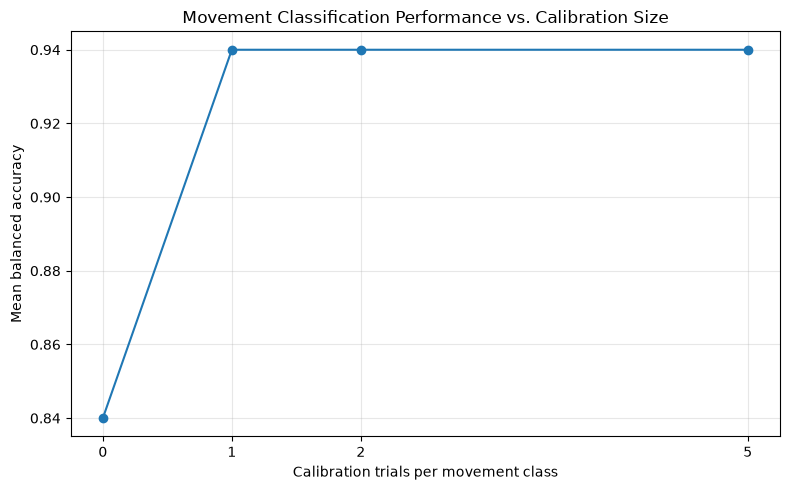

In [18]:
# Calibration curve

plt.figure(figsize=(8, 5))

plt.plot(
    overall_results.index,
    overall_results["balanced_accuracy"],
    marker="o",
)

plt.xticks(
    CALIBRATION_LEVELS
)

plt.xlabel(
    "Calibration trials per movement class"
)

plt.ylabel(
    "Mean balanced accuracy"
)

plt.title(
    "Movement Classification Performance vs. Calibration Size"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()

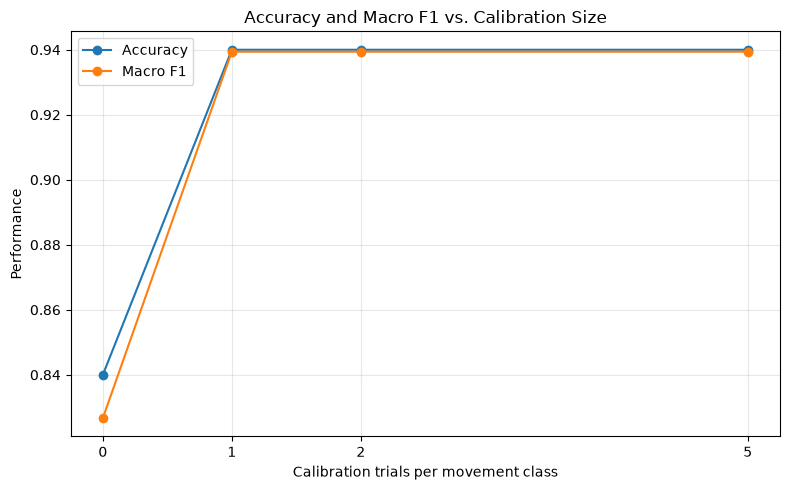

In [19]:
# Accuracy and Macro F1

plt.figure(figsize=(8, 5))

plt.plot(
    overall_results.index,
    overall_results["accuracy"],
    marker="o",
    label="Accuracy",
)

plt.plot(
    overall_results.index,
    overall_results["macro_f1"],
    marker="o",
    label="Macro F1",
)

plt.xticks(
    CALIBRATION_LEVELS
)

plt.xlabel(
    "Calibration trials per movement class"
)

plt.ylabel(
    "Performance"
)

plt.title(
    "Accuracy and Macro F1 vs. Calibration Size"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()

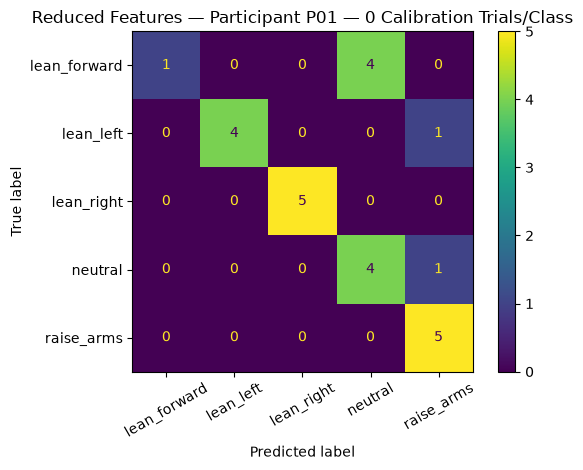

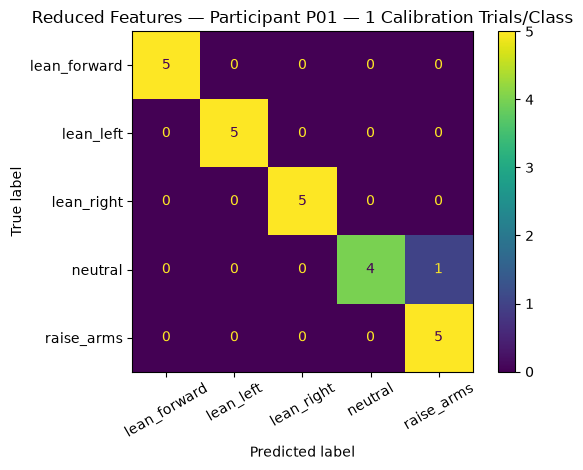

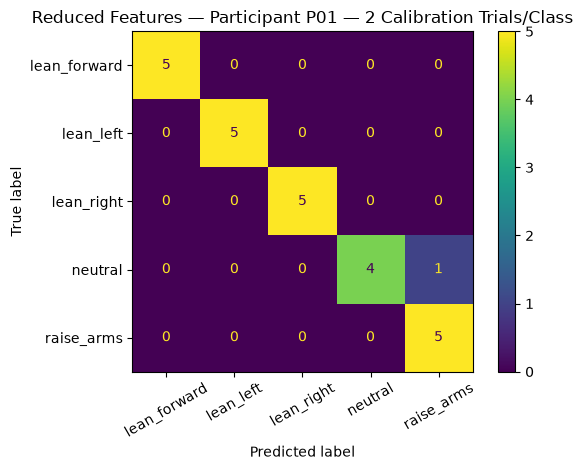

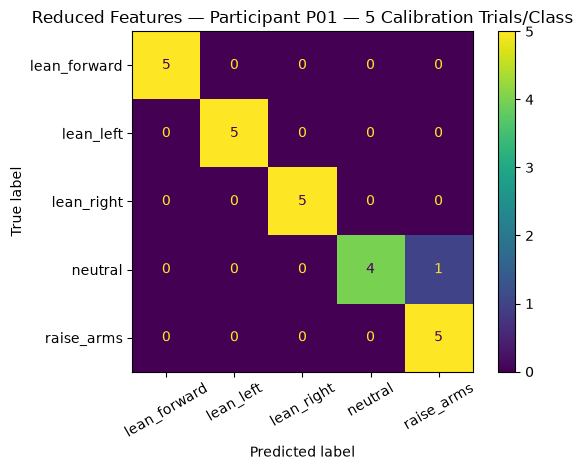

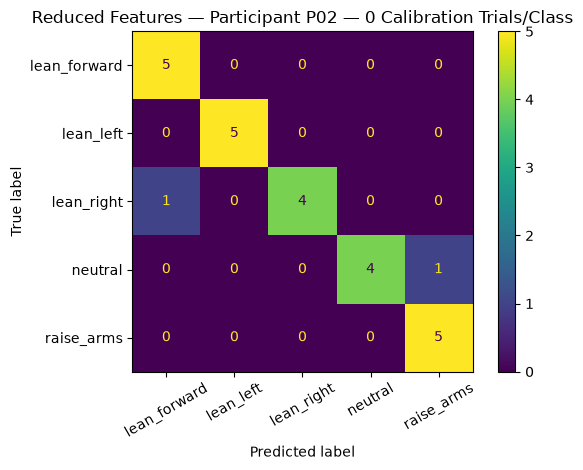

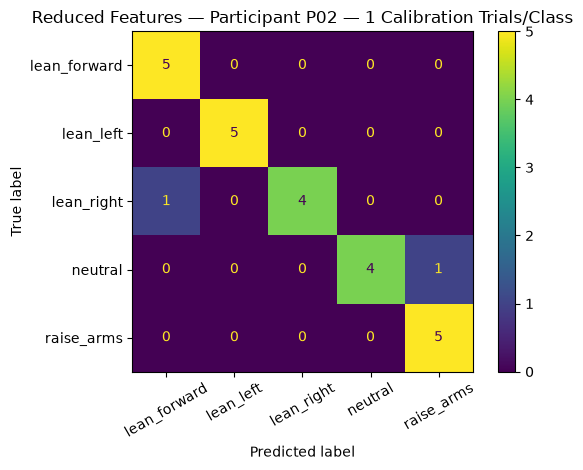

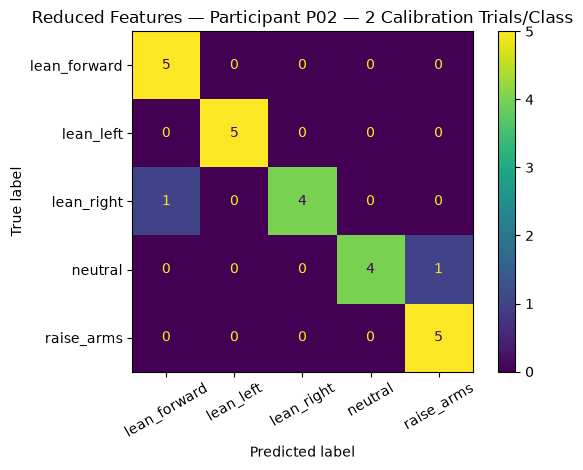

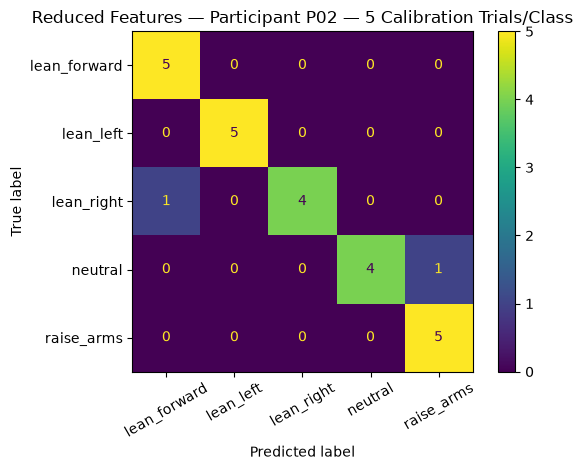

In [20]:
# Confusion matrices

for participant in participants:

    for calibration_level in CALIBRATION_LEVELS:

        matrix = confusion_matrices[
            participant
        ][calibration_level]

        ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=movements,
        ).plot(
            xticks_rotation=30
        )

        plt.title(
            f"Reduced Features — "
            f"Participant {participant} — "
            f"{calibration_level} Calibration Trials/Class"
        )

        plt.tight_layout()
        plt.show()

In [21]:
# Class-level results

class_results = []

for participant in participants:

    for calibration_level in CALIBRATION_LEVELS:

        report = class_reports[
            participant
        ][calibration_level]

        for movement in movements:

            class_results.append(
                {
                    "test_participant": participant,
                    "calibration_per_class": calibration_level,
                    "movement": movement,
                    "precision": (
                        report[movement]["precision"]
                    ),
                    "recall": (
                        report[movement]["recall"]
                    ),
                    "f1": (
                        report[movement]["f1-score"]
                    ),
                }
            )

class_results_df = pd.DataFrame(
    class_results
)

display(
    class_results_df.round(3)
)

,test_participant,calibration_per_class,movement,precision,recall,f1
0,P01,0,lean_forward,1.000,0.2,0.333
1,P01,0,lean_left,1.000,0.8,0.889
2,P01,0,lean_right,1.000,1.0,1.000
3,P01,0,neutral,0.500,0.8,0.615
4,P01,0,raise_arms,0.714,1.0,0.833
5,P01,1,lean_forward,1.000,1.0,1.000
6,P01,1,lean_left,1.000,1.0,1.000
7,P01,1,lean_right,1.000,1.0,1.000
8,P01,1,neutral,1.000,0.8,0.889
9,P01,1,raise_arms,0.833,1.0,0.909


In [22]:
# Check whether the same P01 neutral test trial is misclassified
# across calibration levels.

participant = "P01"

test_data = test_sets[participant].copy()

X_test = test_data[reduced_feature_columns]
y_test = test_data[TARGET_COLUMN]

calibration_pool = calibration_pools[participant]

generic_train_mask = (
    trial_features["participant_id"] != participant
)

X_generic_train = trial_features.loc[
    generic_train_mask,
    reduced_feature_columns,
]

y_generic_train = trial_features.loc[
    generic_train_mask,
    TARGET_COLUMN,
]

for calibration_per_class in CALIBRATION_LEVELS:

    calibration_indices = []

    for movement in movements:

        movement_indices = (
            calibration_pool[
                calibration_pool[TARGET_COLUMN] == movement
            ]
            .sort_values(
                [
                    "session_id",
                    "trial_id",
                ]
            )
            .index
            .tolist()
        )

        calibration_indices.extend(
            movement_indices[:calibration_per_class]
        )

    calibration_data = calibration_pool.loc[
        sorted(calibration_indices)
    ]

    if calibration_per_class == 0:

        X_train = X_generic_train
        y_train = y_generic_train

    else:

        X_train = pd.concat(
            [
                X_generic_train,
                calibration_data[reduced_feature_columns],
            ]
        )

        y_train = pd.concat(
            [
                y_generic_train,
                calibration_data[TARGET_COLUMN],
            ]
        )

    model = create_model()

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(X_test)

    neutral_mask = y_test == "neutral"

    neutral_results = test_data.loc[
        neutral_mask,
        [
            "participant_id",
            "session_id",
            "trial_id",
            "movement_label",
        ],
    ].copy()

    neutral_results["prediction"] = predictions[
        neutral_mask.to_numpy()
    ]

    neutral_results["correct"] = (
        neutral_results["movement_label"]
        == neutral_results["prediction"]
    )

    print(
        f"\nP01 — {calibration_per_class} "
        f"calibration trials/class"
    )

    display(neutral_results)


P01 — 0 calibration trials/class


,participant_id,session_id,trial_id,movement_label,prediction,correct
0,P01,S01,1,neutral,neutral,True
1,P01,S01,2,neutral,raise_arms,False
2,P01,S01,3,neutral,neutral,True
3,P01,S01,4,neutral,neutral,True
4,P01,S01,5,neutral,neutral,True



P01 — 1 calibration trials/class


,participant_id,session_id,trial_id,movement_label,prediction,correct
0,P01,S01,1,neutral,neutral,True
1,P01,S01,2,neutral,raise_arms,False
2,P01,S01,3,neutral,neutral,True
3,P01,S01,4,neutral,neutral,True
4,P01,S01,5,neutral,neutral,True



P01 — 2 calibration trials/class


,participant_id,session_id,trial_id,movement_label,prediction,correct
0,P01,S01,1,neutral,neutral,True
1,P01,S01,2,neutral,raise_arms,False
2,P01,S01,3,neutral,neutral,True
3,P01,S01,4,neutral,neutral,True
4,P01,S01,5,neutral,neutral,True



P01 — 5 calibration trials/class


,participant_id,session_id,trial_id,movement_label,prediction,correct
0,P01,S01,1,neutral,neutral,True
1,P01,S01,2,neutral,raise_arms,False
2,P01,S01,3,neutral,neutral,True
3,P01,S01,4,neutral,neutral,True
4,P01,S01,5,neutral,neutral,True


## Interpretation

This experiment investigates whether participant-specific calibration improves movement classification and how much calibration data is required.

The zero-calibration condition represents the generic cross-participant model. Increasing calibration levels provide progressively more information about the held-out participant while the evaluation set remains fixed. Because the fixed test set consists entirely of Session 01 trials and the calibration pool entirely of Session 02 trials, any improvement must also generalise across recording sessions.

The results show a rapid improvement for P01: balanced accuracy increases from 0.76 without calibration to 0.96 with only one calibration trial per movement class. Increasing calibration from one to two or five trials per class produces no further improvement. P02, in contrast, remains at 0.92 balanced accuracy at every calibration level, including zero calibration.

The pooled improvement is therefore driven entirely by P01 rather than representing a uniform calibration benefit across participants. With only two participants, this suggests that the value of participant-specific calibration may depend on the individual and on how well their movement patterns are already captured by the generic model. It also shows that the relationship between calibration effort and performance is not necessarily gradual: in this experiment, the observed benefit appears as a sharp improvement followed by a plateau.

The class-level results provide a more detailed view of this plateau. For P01, one neutral test trial (Session 01, Trial 2) is consistently classified as `raise_arms` at every calibration level, while the other four neutral trials are classified correctly. Additional participant-specific data therefore does not resolve this particular error. This could reflect an ambiguous recording or a limitation of the current feature representation; distinguishing between these explanations would require inspecting the underlying trial-level movement data rather than relying on the classification output alone.

The results should be interpreted together with the earlier personalised-modelling experiment. That experiment showed that adding 10 participant-specific calibration trials improved mean balanced accuracy from 0.950 to 0.988 using the reduced representation. The current experiment provides a more detailed view of where the benefit emerges: for P01, most of the observed improvement occurs with only one calibration trial per movement class.

Because only two participants are available, these findings remain exploratory and should not be interpreted as evidence that the same calibration requirement or adaptation pattern would hold for a larger population.

## Limitations

This experiment has several limitations:

- only two participants are available
- each participant contributes only two sessions
- only five calibration trials per movement class are available
- the fixed test set contains only five trials per movement class
- calibration trials are selected deterministically rather than across multiple calibration samples
- trial-level aggregation removes temporal structure
- participant and recording session are linked in the current evaluation
- the small number of participants limits the stability of performance estimates
- the calibration-size levels are constrained by the available number of trials

The experiment therefore provides an exploratory estimate of the relationship between calibration effort and participant-specific adaptation rather than a general estimate of the amount of data required for personalisation in a broader population.

## Conclusion

The calibration-size experiment provides a controlled test of how participant-specific data affects movement classification.

By keeping the evaluation trials fixed across calibration levels, the experiment separates the effect of calibration data from changes in the test set.

The reduced 18-feature representation is used because it provided the strongest cross-participant baseline with fewer features in the preceding experiments.

The main result to examine is therefore the relationship between calibration effort and balanced accuracy: whether a small amount of participant-specific data is sufficient to produce meaningful improvement, and whether additional calibration continues to provide useful gains.

## Next Step

The current experiment is limited by the small number of participants and deterministic calibration selection.

A useful next step would be to expand the dataset with additional participants and repeated recording sessions.

With more participants, the calibration-size experiment could be repeated using multiple calibration samples or resampling strategies, allowing the variability of adaptation performance to be estimated.

This would provide a stronger test of whether participant-specific calibration consistently improves embodied interaction models across different people.